In [1]:
import pandas as pd

# Import functions from all the necessary modules
from function.DataHandling import (
    getData,
    initData,
    # cleanData,
    splitData,
)
from function.DataExploration import (
    plotCorrelationMatrix,
    plotPairwiseRelationships,
    plotPCA,
    plotKmeansClusters,
    plotSilhouetteScore,
    plotFeatureImportance,
    plotCategoricalDistribution,
    plotNumericalDistribution,
    plotHistogram,
    plotBoxplot,
    plotScatter,
)

In [2]:
# Had to move this here as it would not work if left in the other file
def cleanData(df: pd.DataFrame) -> pd.DataFrame:
    """
    This function cleans the data by removing unnecessary columns and handling missing values.
    It returns a cleaned DataFrame.
    """
    df = df.copy()

    # Turn Stage into numerical values
    df["Stage"] = df["Stage"].map(
        {
            "I": 1,
            "II": 2,
            "III": 3,
            "IV": 4,
        }
    )

    # Convert Male/Female to 0/1
    df["Gender"] = df["Gender"].map(
        {
            "Male": 0,
            "Female": 1,
        }
    )

    # Convert Yes/No to 0/1
    df["FamilyHistory"] = df["FamilyHistory"].map(
        {
            "Yes": 1,
            "No": 0,
        }
    )
    df["Recurrence"] = df["Recurrence"].map(
        {
            "Yes": 1,
            "No": 0,
        }
    )

    oneHot = [
        "CancerType",
        "TreatmentResponse",
        "Race/Ethnicity",
        "SmokingStatus",
        "TreatmentType",
        "GeneticMarker",
    ]
    # df = pd.get_dummies(df, columns=oneHot, drop_first=True)
    # Convert TreatmentResponse to numerical values
    df["TreatmentResponse"] = df["TreatmentResponse"].map(
        {
            "Complete Remission": 1,
            "Partial Remission": 2,
            "No Response": 3,
        }
    )

    # Convert Ethnicity to numerical values
    df["Race/Ethnicity"] = df["Race/Ethnicity"].map(
        {
            "Caucasian": 1,
            "African American": 2,
            "Hispanic": 3,
            "Asian": 4,
            "Other": 5,
        }
    )

    # Convert SmokingStatus to numerical values
    df["SmokingStatus"] = df["SmokingStatus"].map(
        {
            "Non-Smoker": 1,
            "Former Smoker": 2,
            "Smoker": 3,
        }
    )

    # Convert TreatmentType to numerical values
    df["TreatmentType"] = df["TreatmentType"].map(
        {
            "Chemotherapy": 1,
            "Radiation": 2,
            "Surgery": 3,
            "Combination Therapy": 4,
        }
    )

    # Convert GeneticMarker to numerical values
    df["GeneticMarker"] = df["GeneticMarker"].map(
        {
            "BRCA1": 1,
            "KRAS": 2,
            "EGFR": 3,
        }
    )

    # Convert CancerType to numerical values
    df["CancerType"] = df["CancerType"].map(
        {
            "Breast": 1,
            "Colon": 2,
            "Prostate": 3,
            "Lung": 4,
            "Leukemia": 5,
            "Skin": 6,
        }
    )

    # Nan
    df["GeneticMarker"].fillna(0, inplace=True)
    # Drop unnecessary columns
    df.drop(columns=["HospitalRegion"], inplace=True)

    return df

In [3]:
# Get the data
data = getData()
# Initial Statistics
initData(data)
# Clean the data
clean_data = cleanData(data)
initData(clean_data)

Shape of the data: (17686, 16)
Summary statistics:
           PatientID           Age           BMI     TumorSize  SurvivalMonths
count  17686.000000  17686.000000  17686.000000  17686.000000    17686.000000
mean    8843.500000     53.758396     29.253805      5.499751       60.387821
std     5105.652766     21.079473      6.203575      2.603107       34.794859
min        1.000000     18.000000     18.500000      1.000000        1.000000
25%     4422.250000     35.000000     23.900000      3.300000       30.000000
50%     8843.500000     54.000000     29.200000      5.500000       60.000000
75%    13264.750000     72.000000     34.600000      7.700000       91.000000
max    17686.000000     90.000000     40.000000     10.000000      120.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17686 entries, 0 to 17685
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PatientID          17686 non-null  i

/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_27655/1407713911.py:111: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["GeneticMarker"].fillna(0, inplace=True)


In [4]:
print(data["CancerType"].unique())

['Breast' 'Colon' 'Prostate' 'Lung' 'Leukemia' 'Skin']


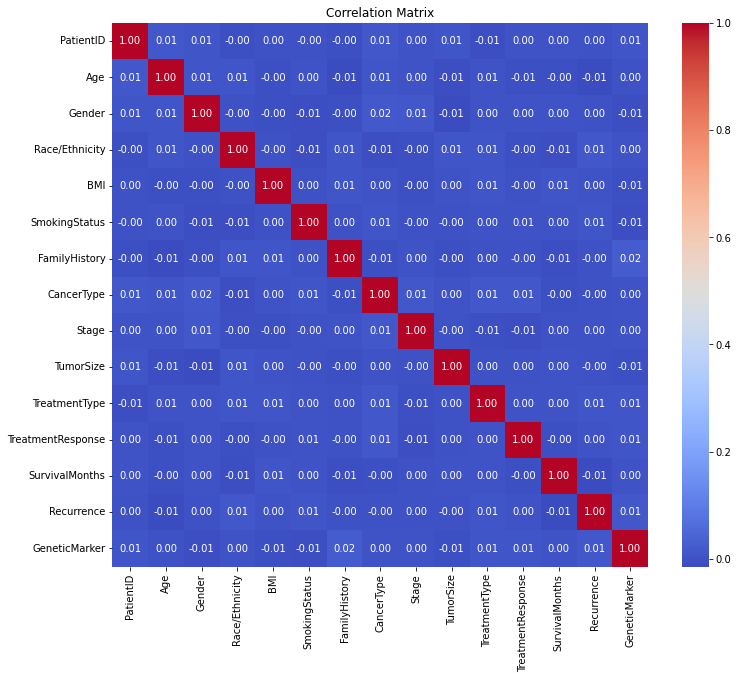

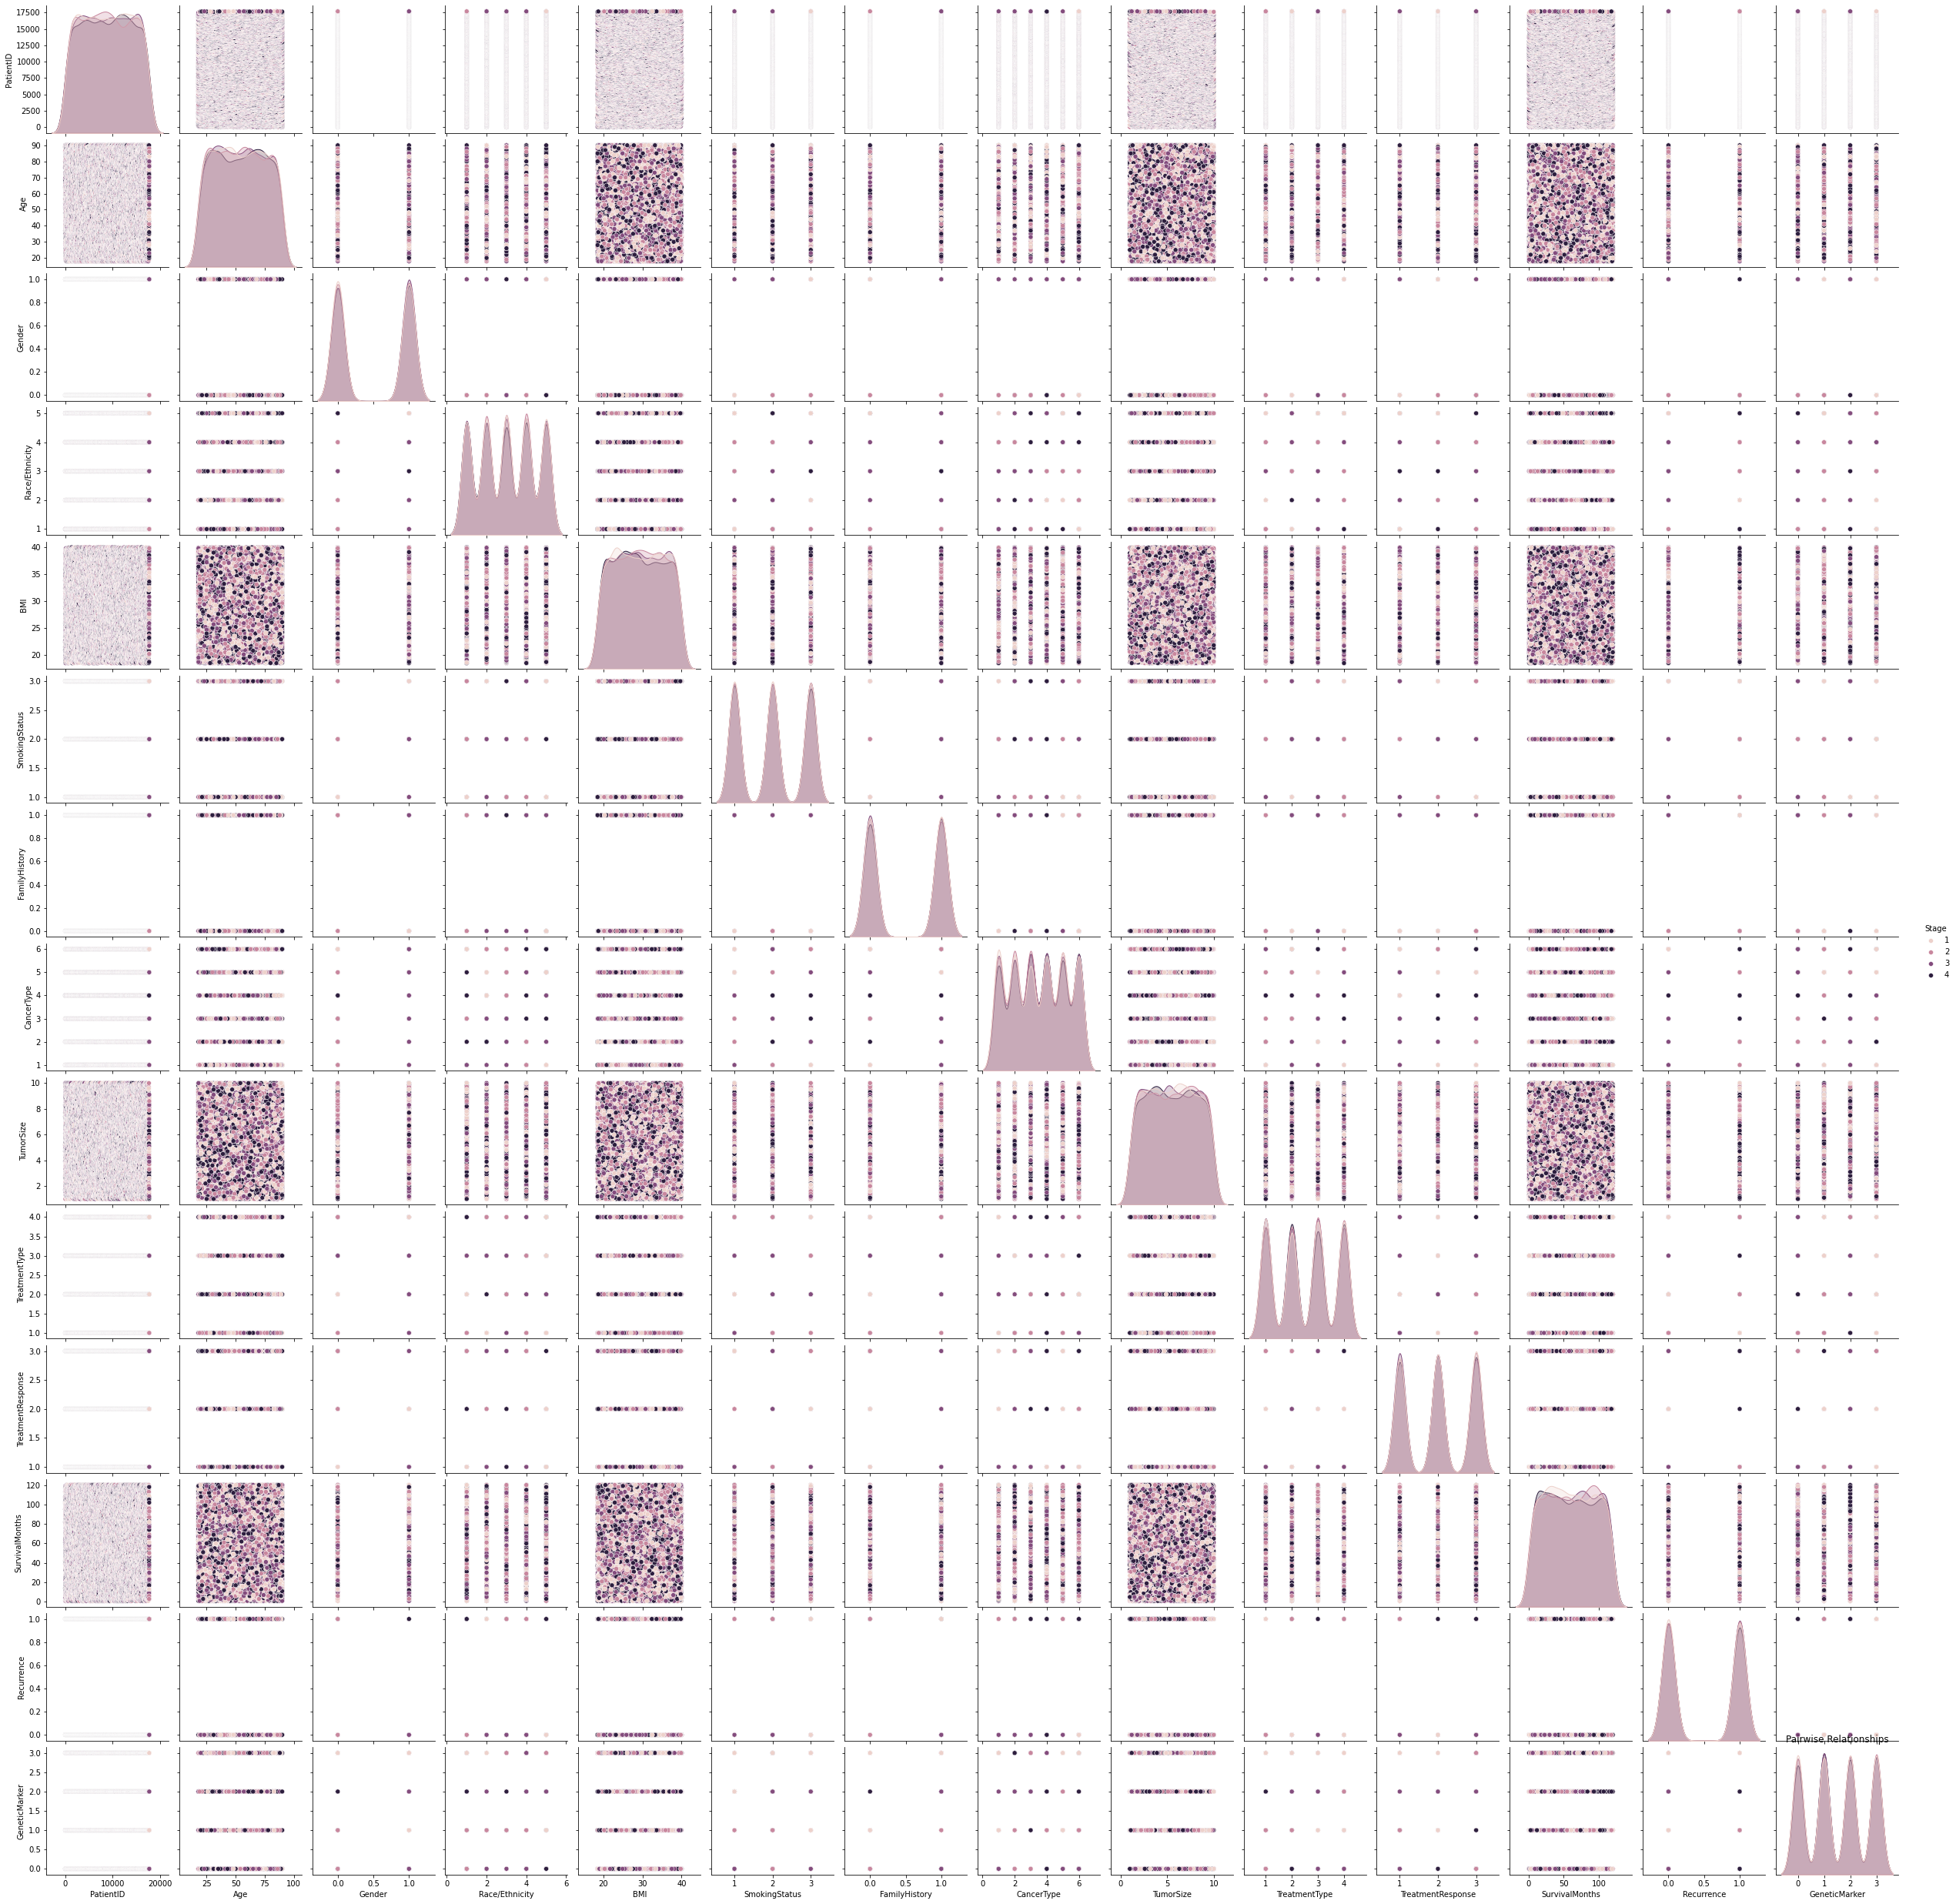

IndexError: index 1 is out of bounds for axis 1 with size 1

<Figure size 720x432 with 0 Axes>

In [ ]:
# Plot some graphs
plotCorrelationMatrix(clean_data)
plotPairwiseRelationships(clean_data)

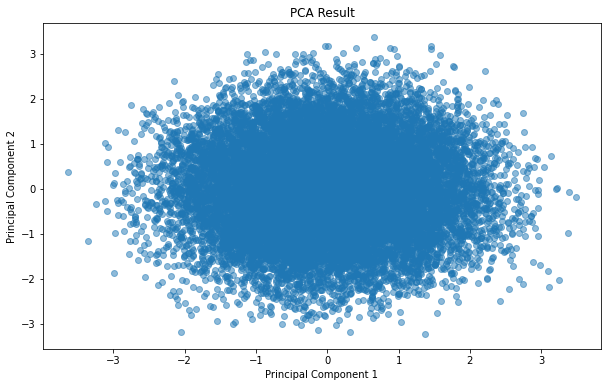

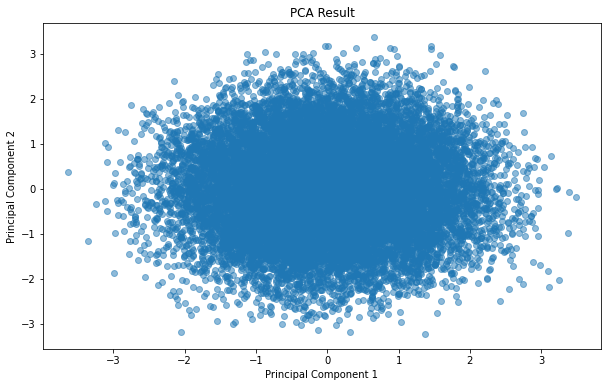

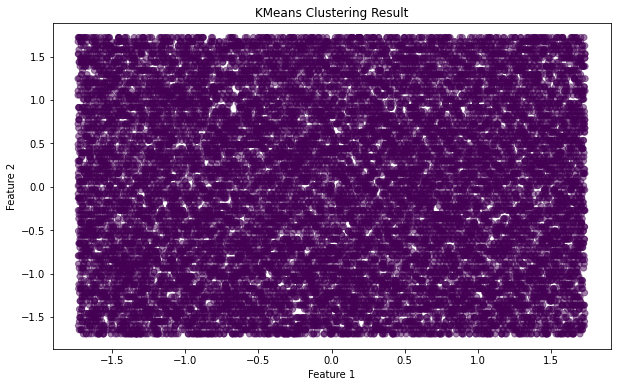

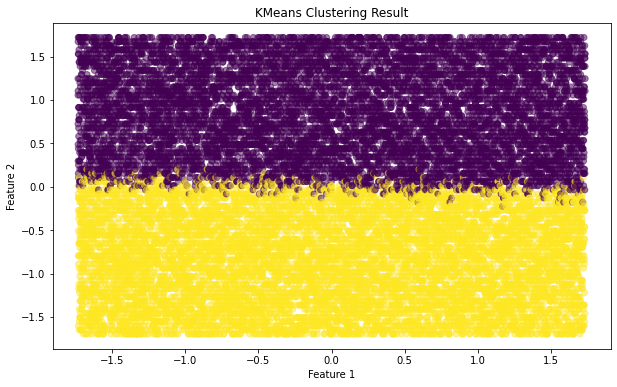

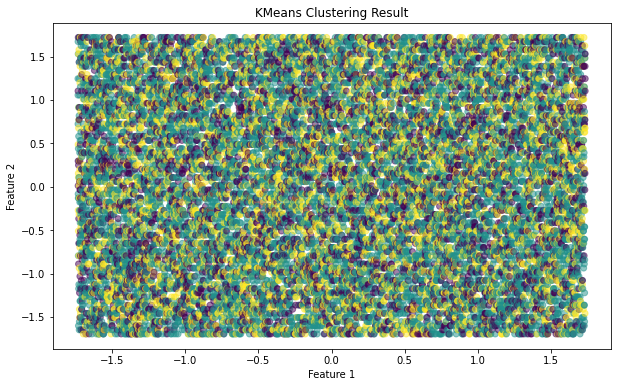

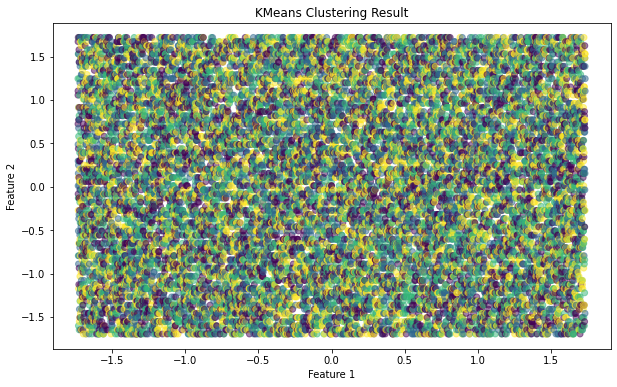

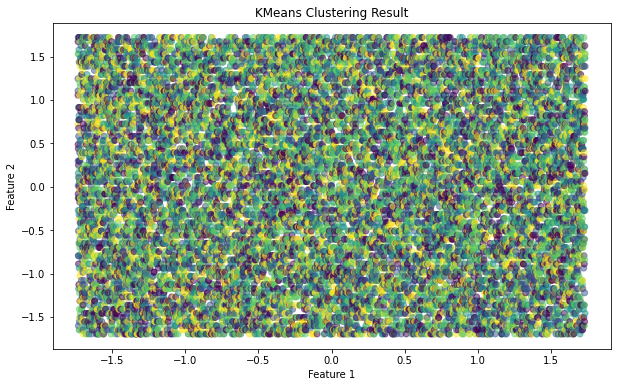

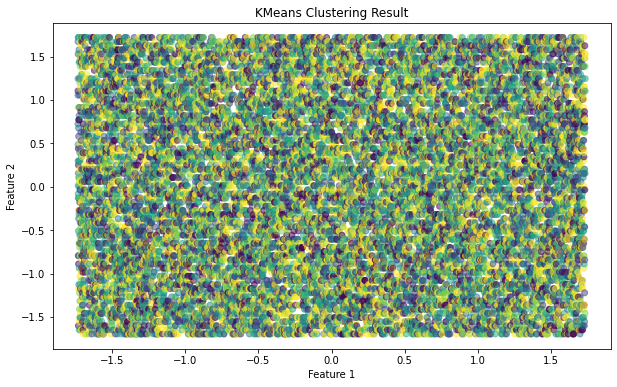

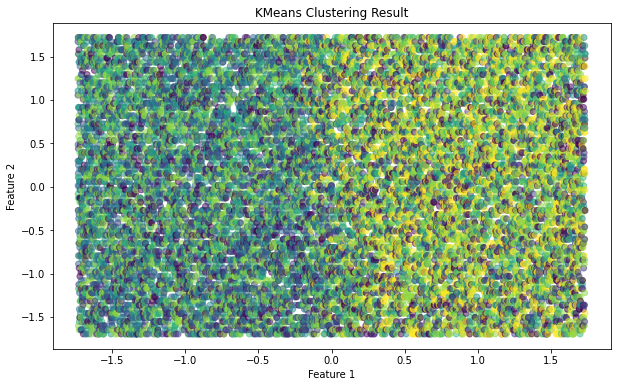

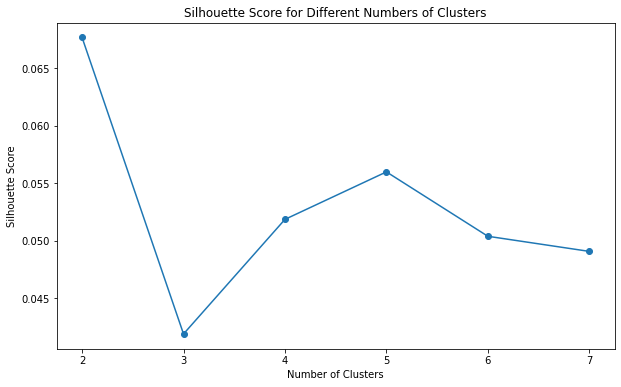

KeyError: "['TreatementResponse'] not found in axis"

In [ ]:
# Plot series of PCA
for i in range(2, 4):
    plotPCA(clean_data, i)
# Plot Kmeans clusters
for i in range(1, 8):
    plotKmeansClusters(clean_data, i)
# Plot Silhouette Score
plotSilhouetteScore(clean_data, range(2, 8))

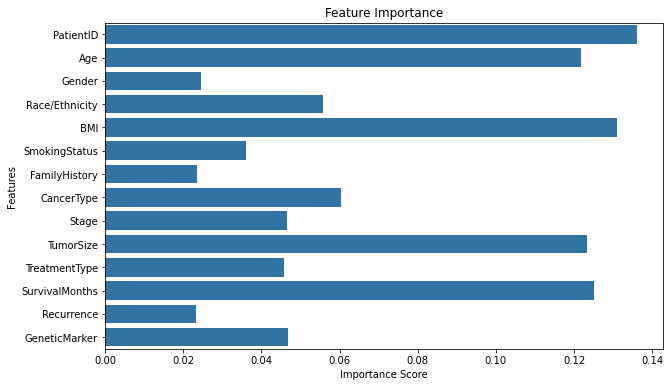

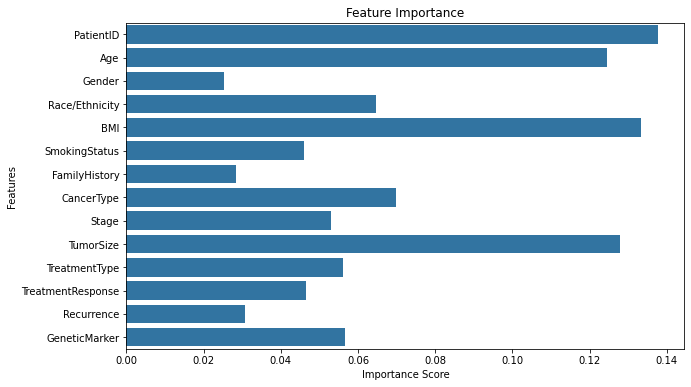

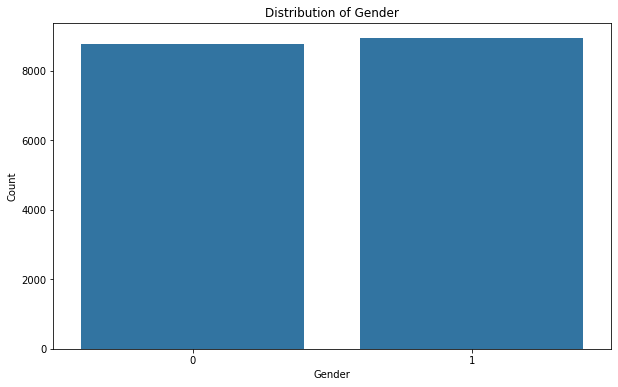

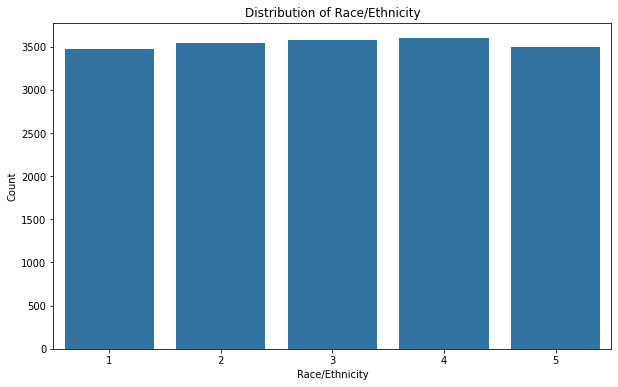

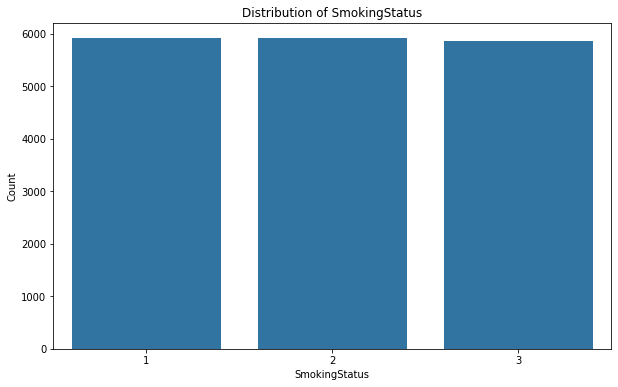

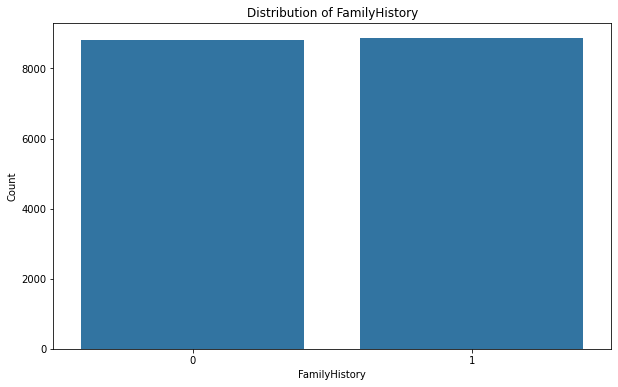

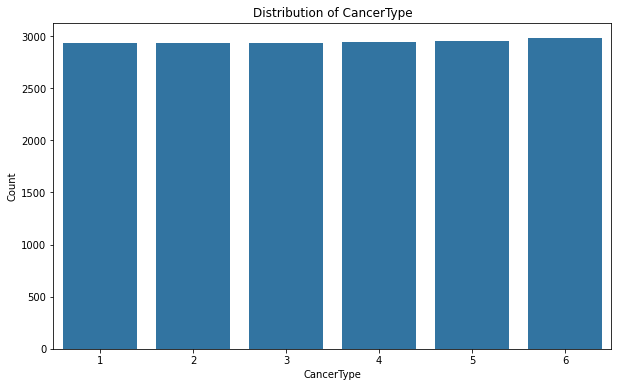

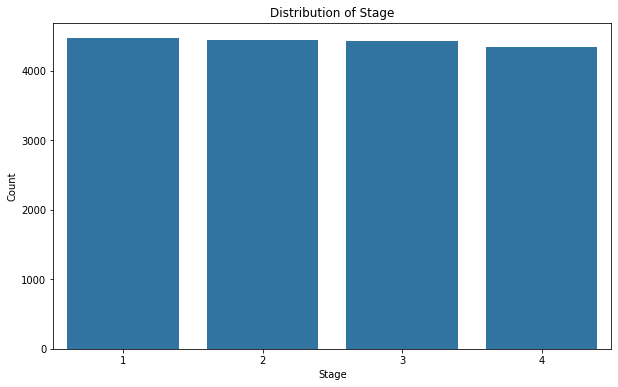

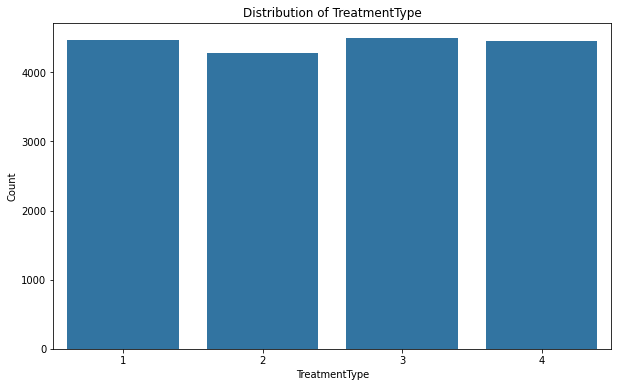

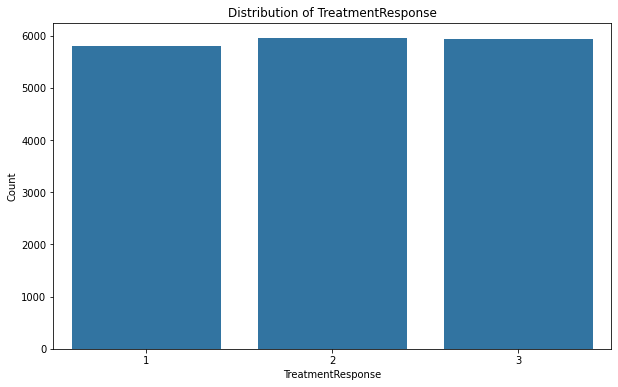

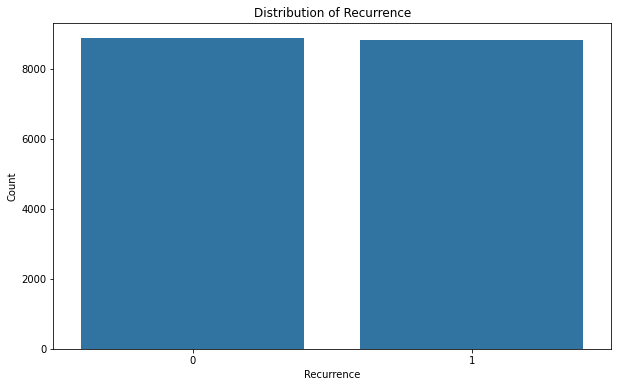

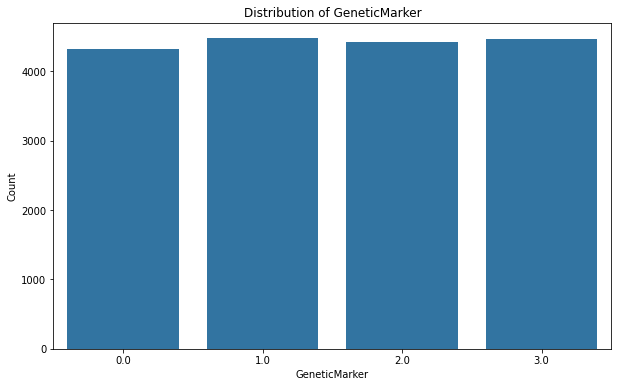

ValueError: Could not interpret value `HospitalRegion` for `x`. An entry with this name does not appear in `data`.

<Figure size 720x432 with 0 Axes>

In [ ]:
# Plot Feature Importance
targetFeature = ["TreatmentResponse", "SurvivalMonths"]
for i in targetFeature:
    plotFeatureImportance(clean_data, i)

# Plot Categorical Distribution
for i in data.select_dtypes(include=["object"]).columns:
    plotCategoricalDistribution(clean_data, i)

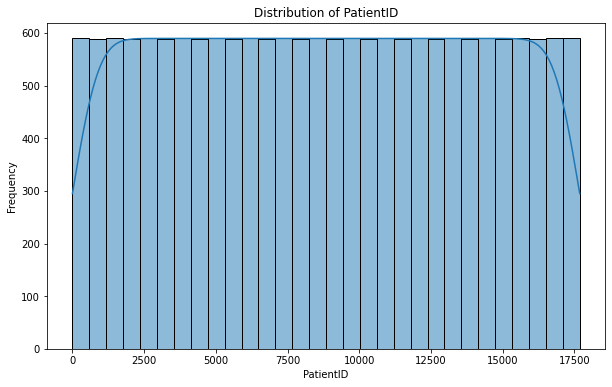

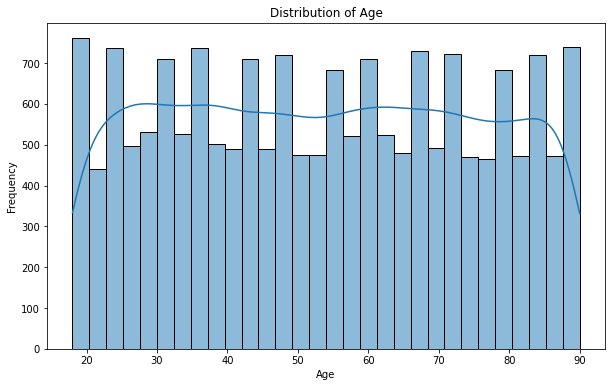

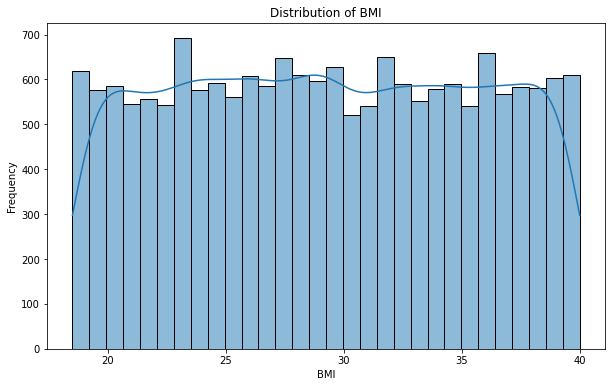

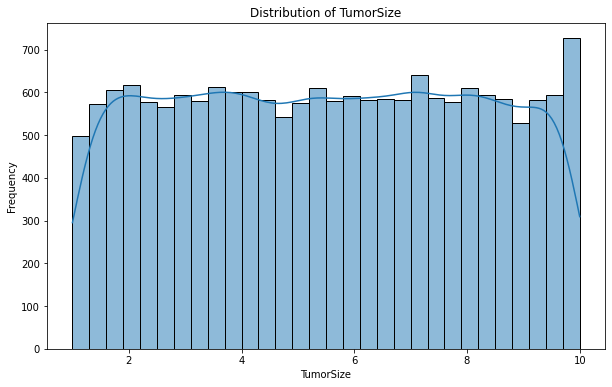

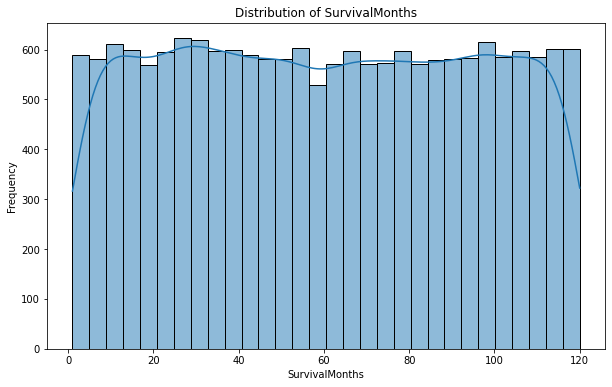

In [10]:
# Plot Numerical Distribution
for i in data.select_dtypes(include=["float64", "int64"]).columns:
    plotNumericalDistribution(clean_data, i)